
# 01 — Decision Boundary Analysis
## Football Decision Engine

**Notebook purpose**

> This notebook is fully executed for reproducibility and interpretability.

This notebook translates the Football Decision Engine into a decision-intelligence artifact that a performance department, coaching staff, or technical leadership group could review.

The goal is not simply to visualize model behavior, but to answer four operational questions:

1. **What action does the current policy recommend across the risk–value space?**
2. **How does the optimization layer reinterpret those same player states?**
3. **Where do policy and utility disagree, and why does that matter?**
4. **What football conclusions should a club draw from the current formulation?**

The notebook is therefore designed as a senior portfolio piece: interpretable, structured, and explicit about both strengths and calibration gaps.



## Notebook structure

1. Reconstruct the current decision policy in notebook form  
2. Build the full decision surface across `risk_score` and `value_score`  
3. Visualize the conceptual policy boundary  
4. Inspect boundary transitions through cross-sections  
5. Recreate the optimization-layer utilities  
6. Quantify policy vs utility disagreement  
7. Review representative football archetypes  
8. Test sensitivity to risk aversion  
9. Conclude with football and modeling implications


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from dataclasses import dataclass

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:0.3f}")



## 1. Policy reconstruction

The repository implements a **policy-driven** decision layer over two normalized inputs:

- `risk_score ∈ [0, 1]`
- `value_score ∈ [0, 1]`

At the current rule level, the logic is intentionally simple and interpretable:

- **High risk + low value** → `bench`
- **High risk + high value** → `limit_minutes`
- **Low risk** → `start`

This reflects a practical football principle:

- availability enables selection
- value justifies exposure
- risk constrains usage

For the notebook we reconstruct the same policy in a self-contained way so that the full state space can be analyzed end to end.


In [2]:

@dataclass(frozen=True)
class DecisionThresholds:
    high_risk: float
    high_value: float


@dataclass(frozen=True)
class DecisionActions:
    high_risk_low_value: str
    high_risk_high_value: str
    low_risk: str


# Boundary analysis uses the same working policy structure as the project.
thresholds = DecisionThresholds(
    high_risk=0.60,
    high_value=0.65,
)

actions = DecisionActions(
    high_risk_low_value="bench",
    high_risk_high_value="limit_minutes",
    low_risk="start",
)

optimization_config = {
    "risk_penalty": 0.50,
    "extra_start_penalty": 0.20,
    "bench_multiplier": 0.30,
}

thresholds, actions, optimization_config


(DecisionThresholds(high_risk=0.6, high_value=0.65),
 DecisionActions(high_risk_low_value='bench', high_risk_high_value='limit_minutes', low_risk='start'),
 {'risk_penalty': 0.5, 'extra_start_penalty': 0.2, 'bench_multiplier': 0.3})


### Policy note

These values are used here as operational parameters for boundary analysis. In a production setting, they would be calibrated from club-specific decision preferences, including:

- medical and performance risk tolerance
- fixture congestion
- substitution strategy
- role-specific depth
- match importance
- opponent-adjusted upside

That distinction matters: the notebook is not claiming that these numbers are universally correct. It is showing how the **current project formulation behaves**.


In [3]:

def classify_decision(
    risk_score: float,
    value_score: float,
    thresholds: DecisionThresholds,
    actions: DecisionActions,
) -> str:
    if not 0.0 <= risk_score <= 1.0:
        raise ValueError("risk_score must be between 0 and 1.")
    if not 0.0 <= value_score <= 1.0:
        raise ValueError("value_score must be between 0 and 1.")

    is_high_risk = risk_score >= thresholds.high_risk
    is_high_value = value_score >= thresholds.high_value

    if is_high_risk and not is_high_value:
        return actions.high_risk_low_value
    if is_high_risk and is_high_value:
        return actions.high_risk_high_value
    return actions.low_risk



## 2. Build the full decision surface

To move beyond isolated examples, we evaluate the full state space on a dense grid. Each point represents a hypothetical player state defined only by `risk_score` and `value_score`.

This is useful because it shows the complete decision geometry of the policy rather than a few anecdotal cases.


In [4]:

risk_grid = np.linspace(0, 1, 201)
value_grid = np.linspace(0, 1, 201)

grid = pd.DataFrame(
    [(r, v) for r in risk_grid for v in value_grid],
    columns=["risk_score", "value_score"],
)

grid["decision"] = [
    classify_decision(r, v, thresholds=thresholds, actions=actions)
    for r, v in zip(grid["risk_score"], grid["value_score"])
]

grid.head()


,risk_score,value_score,decision
0,0.000,0.000,start
1,0.000,0.005,start
2,0.000,0.010,start
3,0.000,0.015,start
4,0.000,0.020,start


In [5]:

decision_map = {"bench": 0, "limit_minutes": 1, "start": 2}
grid["decision_code"] = grid["decision"].map(decision_map)

surface = (
    grid.pivot(index="value_score", columns="risk_score", values="decision_code")
    .sort_index(ascending=True)
)

surface.iloc[:5, :5]


risk_score,0.000,0.005,0.010,0.015,0.020
value_score,,,,,
0.000,2,2,2,2,2
0.005,2,2,2,2,2
0.010,2,2,2,2,2
0.015,2,2,2,2,2
0.020,2,2,2,2,2



## 3. Visualize the conceptual policy boundary

This first figure is the governing map of the rule-based layer.

It makes the threshold structure explicit:

- vertical line → `high_risk`
- horizontal line → `high_value`

From a decision-governance perspective, this is a strong asset: staff can see immediately how the system turns player states into actions.


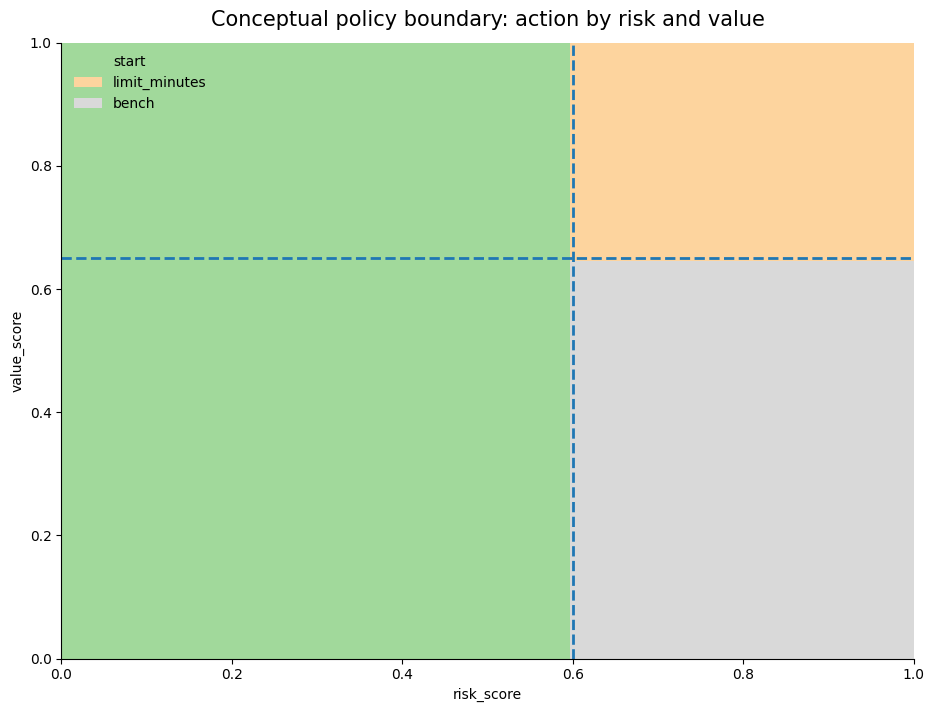

In [6]:

fig, ax = plt.subplots(figsize=(11, 8))

policy_cmap = ListedColormap(["#d9d9d9", "#fdd49e", "#a1d99b"])
ax.imshow(
    surface.values,
    origin="lower",
    aspect="auto",
    extent=[0, 1, 0, 1],
    cmap=policy_cmap,
    interpolation="nearest",
)

ax.axvline(thresholds.high_risk, linestyle="--", linewidth=2)
ax.axhline(thresholds.high_value, linestyle="--", linewidth=2)

ax.set_title("Conceptual policy boundary: action by risk and value", fontsize=15, pad=12)
ax.set_xlabel("risk_score")
ax.set_ylabel("value_score")

legend_elements = [
    Patch(facecolor="#a1d99b", edgecolor="none", label="start"),
    Patch(facecolor="#fdd49e", edgecolor="none", label="limit_minutes"),
    Patch(facecolor="#d9d9d9", edgecolor="none", label="bench"),
]
ax.legend(handles=legend_elements, loc="upper left", frameon=False)
plt.show()



### Reading the policy plot like a practitioner

Three operational messages are immediately visible:

- The policy is **availability-first**: all low-risk states become `start`
- The policy creates a distinct **controlled exposure zone** for high-risk but high-value players
- The weakest states combine high risk with low value and are assigned `bench`

This is exactly why a rule-based layer is useful in football operations: it provides governance, interpretability, and a common language across technical and non-technical stakeholders.



## 4. Boundary cross-sections

Heatmaps are useful globally, but line cuts are often easier to discuss in decision meetings.

We therefore inspect the surface from two perspectives:

1. Fix `value_score` and vary `risk_score`  
2. Fix `risk_score` and vary `value_score`


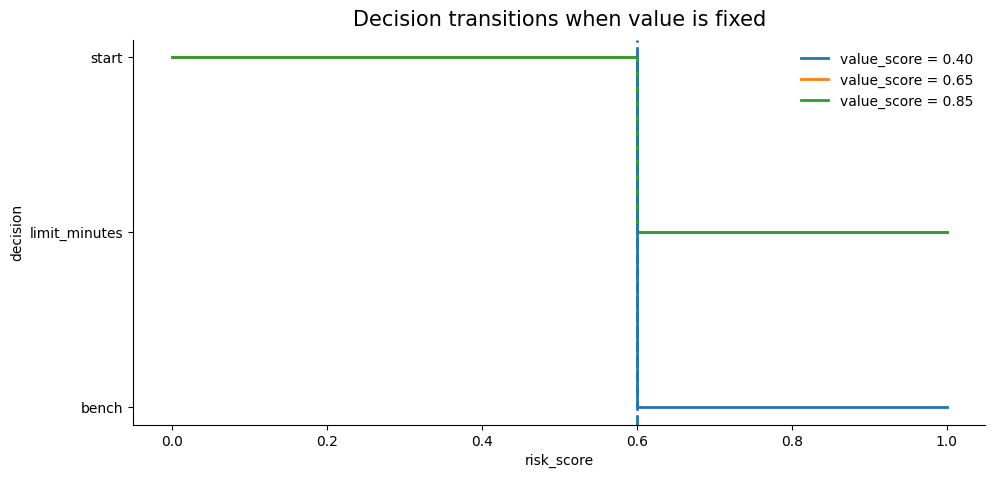

In [7]:

fixed_values = [0.40, 0.65, 0.85]
risk_line = np.linspace(0, 1, 101)

fig, ax = plt.subplots(figsize=(11, 5))

for fixed_value in fixed_values:
    decisions = [
        classify_decision(risk, fixed_value, thresholds, actions)
        for risk in risk_line
    ]
    codes = [decision_map[d] for d in decisions]
    ax.step(risk_line, codes, where="post", linewidth=2, label=f"value_score = {fixed_value:.2f}")

ax.axvline(thresholds.high_risk, linestyle="--", linewidth=2)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["bench", "limit_minutes", "start"])
ax.set_xlabel("risk_score")
ax.set_ylabel("decision")
ax.set_title("Decision transitions when value is fixed", fontsize=15, pad=10)
ax.legend(frameon=False)
plt.show()


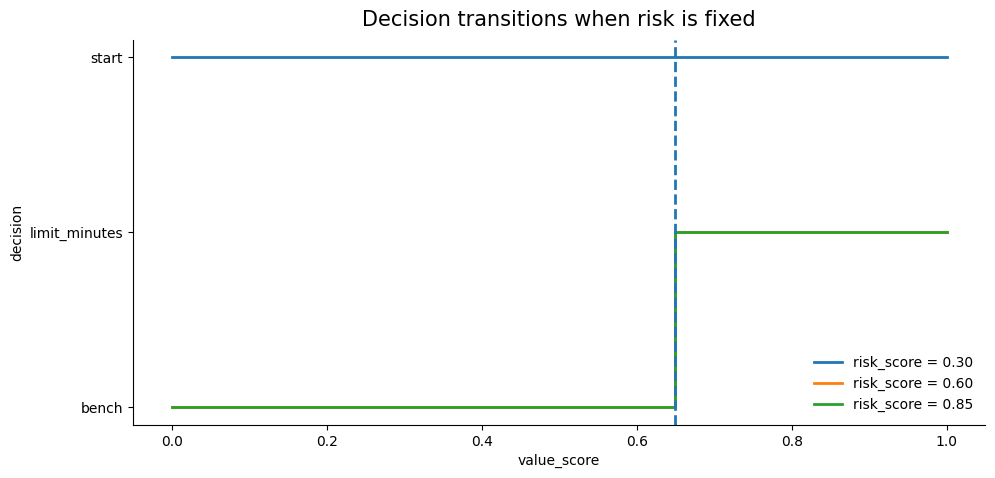

In [8]:

fixed_risks = [0.30, 0.60, 0.85]
value_line = np.linspace(0, 1, 101)

fig, ax = plt.subplots(figsize=(11, 5))

for fixed_risk in fixed_risks:
    decisions = [
        classify_decision(fixed_risk, value, thresholds, actions)
        for value in value_line
    ]
    codes = [decision_map[d] for d in decisions]
    ax.step(value_line, codes, where="post", linewidth=2, label=f"risk_score = {fixed_risk:.2f}")

ax.axvline(thresholds.high_value, linestyle="--", linewidth=2)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["bench", "limit_minutes", "start"])
ax.set_xlabel("value_score")
ax.set_ylabel("decision")
ax.set_title("Decision transitions when risk is fixed", fontsize=15, pad=10)
ax.legend(frameon=False)
plt.show()



### Cross-section insight

The rule system is deliberately **piecewise constant**. That has two consequences:

- it is highly auditable and easy to communicate
- it introduces abrupt action changes around thresholds

In practice, that means borderline players deserve contextual review. The policy is useful as a baseline, but not sufficient as a complete football decision process.



## 5. Utility analysis behind the optimization layer

The project does not stop at policy assignment. It also defines a utility structure used by the optimization layer:

- `base_score = value_score - risk_penalty * risk_score`
- `U_start = base_score - extra_start_penalty * risk_score`
- `U_limit = base_score`
- `U_bench = bench_multiplier * base_score`

This matters because the engine is no longer asking only **which bucket a player belongs to**, but **which action yields the best trade-off under risk-aware utility**.


In [9]:

risk_penalty = optimization_config["risk_penalty"]
extra_start_penalty = optimization_config["extra_start_penalty"]
bench_multiplier = optimization_config["bench_multiplier"]

grid["base_score"] = grid["value_score"] - risk_penalty * grid["risk_score"]
grid["u_start"] = grid["base_score"] - extra_start_penalty * grid["risk_score"]
grid["u_limit"] = grid["base_score"]
grid["u_bench"] = bench_multiplier * grid["base_score"]

utility_cols = ["u_start", "u_limit", "u_bench"]
utility_action_map = {
    "u_start": "start",
    "u_limit": "limit_minutes",
    "u_bench": "bench",
}

grid["best_action_by_utility"] = (
    grid[utility_cols]
    .idxmax(axis=1)
    .map(utility_action_map)
)

grid[["risk_score", "value_score", "base_score", "u_start", "u_limit", "u_bench", "best_action_by_utility"]].head()


,risk_score,value_score,base_score,u_start,u_limit,u_bench,best_action_by_utility
0,0.000,0.000,0.000,0.000,0.000,0.000,start
1,0.000,0.005,0.005,0.005,0.005,0.002,start
2,0.000,0.010,0.010,0.010,0.010,0.003,start
3,0.000,0.015,0.015,0.015,0.015,0.004,start
4,0.000,0.020,0.020,0.020,0.020,0.006,start


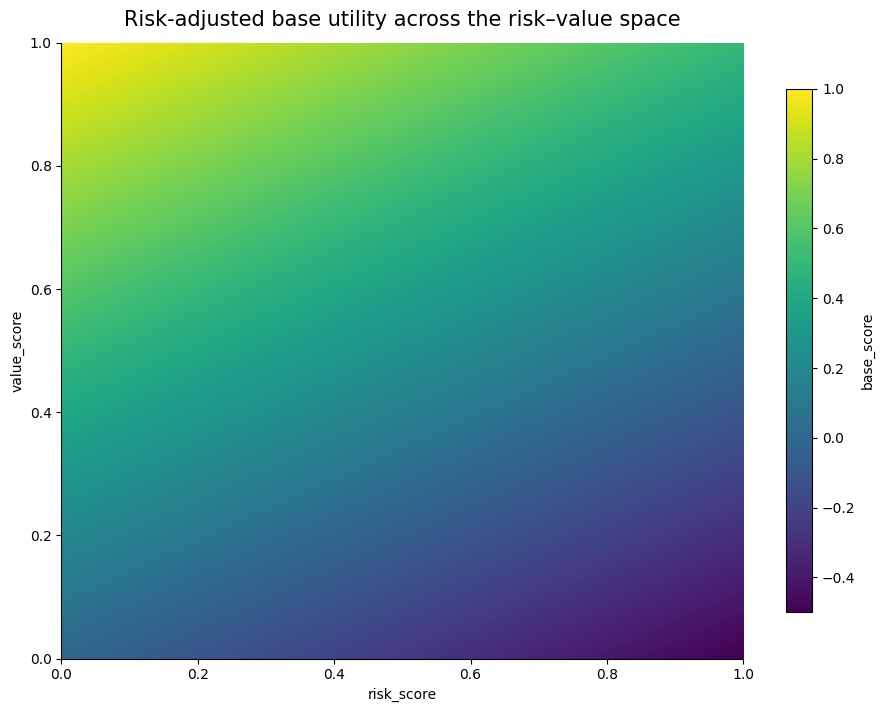

In [10]:

utility_surface = (
    grid.pivot(index="value_score", columns="risk_score", values="base_score")
    .sort_index(ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(
    utility_surface.values,
    origin="lower",
    aspect="auto",
    extent=[0, 1, 0, 1],
    interpolation="nearest",
)
ax.set_title("Risk-adjusted base utility across the risk–value space", fontsize=15, pad=12)
ax.set_xlabel("risk_score")
ax.set_ylabel("value_score")
cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("base_score")
plt.show()


C:\Users\manue\AppData\Local\Temp\ipykernel_19520\2515159133.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(decision_map)


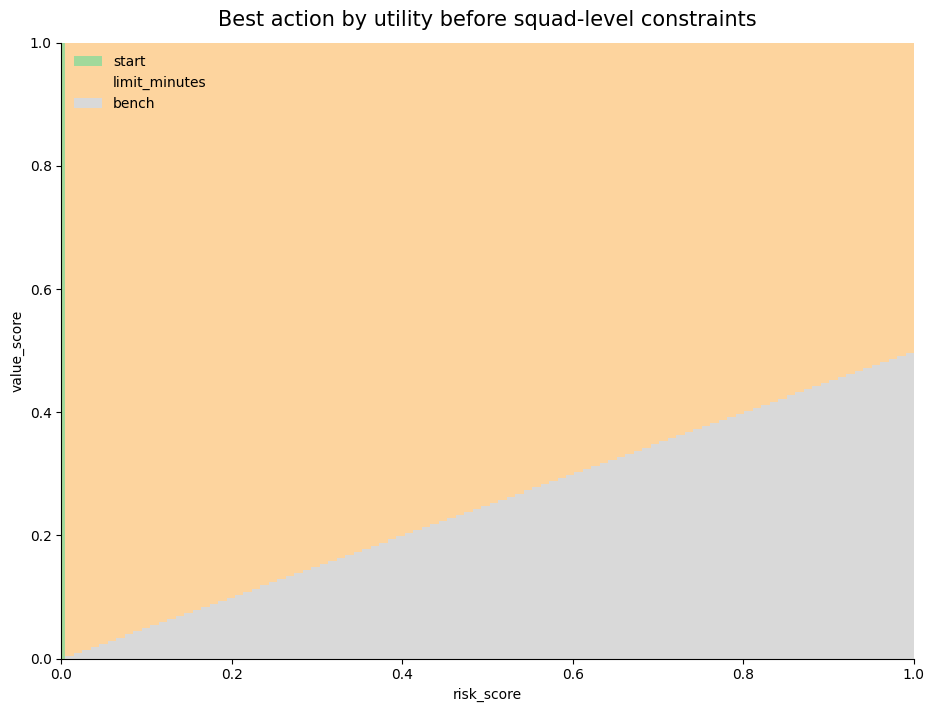

In [11]:

best_action_surface = (
    grid.pivot(index="value_score", columns="risk_score", values="best_action_by_utility")
    .replace(decision_map)
    .sort_index(ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 8))
ax.imshow(
    best_action_surface.values,
    origin="lower",
    aspect="auto",
    extent=[0, 1, 0, 1],
    cmap=policy_cmap,
    interpolation="nearest",
)
ax.set_title("Best action by utility before squad-level constraints", fontsize=15, pad=12)
ax.set_xlabel("risk_score")
ax.set_ylabel("value_score")
ax.legend(handles=legend_elements, loc="upper left", frameon=False)
plt.show()



### Utility interpretation

This is the first major modeling insight of the notebook.

The policy boundary is interpretable and threshold-based. The utility layer is continuous and trade-off-based. In the current formulation, `limit_minutes` is structurally attractive because:

- it avoids the extra starter penalty applied to risky exposure
- it preserves the full `base_score`
- `bench` keeps only a fraction of player value

That means the utility layer is not merely a restatement of the policy. It is a **different decision logic**, and that difference should be explicitly diagnosed.



### Policy vs utility mismatch

A senior review should not stop at plotting both surfaces. It should quantify where they disagree.


In [12]:

grid["is_mismatch"] = grid["decision"] != grid["best_action_by_utility"]

mismatch_rate = grid["is_mismatch"].mean()

action_mix_policy = (
    grid["decision"].value_counts(normalize=True)
    .rename("policy_share")
    .reset_index().rename(columns={"index": "action"})
)

action_mix_utility = (
    grid["best_action_by_utility"].value_counts(normalize=True)
    .rename("utility_share")
    .reset_index().rename(columns={"index": "action"})
)

mismatch_summary = (
    grid.groupby(["decision", "best_action_by_utility"])
    .size()
    .rename("n_states")
    .reset_index()
    .sort_values("n_states", ascending=False)
)

print(f"Mismatch rate across the full state space: {mismatch_rate:.2%}")
print()
print("Policy action mix")
display(action_mix_policy)
print("Utility-implied action mix")
display(action_mix_utility)
print("Largest policy → utility transitions")
display(mismatch_summary.head(10))


Mismatch rate across the full state space: 69.18%

Policy action mix


,decision,policy_share
0,start,0.597
1,bench,0.261
2,limit_minutes,0.142


Utility-implied action mix


,best_action_by_utility,utility_share
0,limit_minutes,0.745
1,bench,0.250
2,start,0.005


Largest policy → utility transitions


,decision,best_action_by_utility,n_states
4,start,limit_minutes,20319
0,bench,bench,6500
2,limit_minutes,limit_minutes,5751
1,bench,limit_minutes,4030
3,start,bench,3600
5,start,start,201



### Utility gap and decision confidence

The **utility gap** is the difference between the best and second-best actions at each point in the state space.

- small gap → fragile decision, easy to flip with small score changes  
- large gap → robust decision, stable under local perturbations


In [13]:

sorted_utilities = np.sort(grid[utility_cols].values, axis=1)
grid["utility_gap"] = sorted_utilities[:, -1] - sorted_utilities[:, -2]

grid[["risk_score", "value_score", "best_action_by_utility", "utility_gap"]].head()


,risk_score,value_score,best_action_by_utility,utility_gap
0,0.000,0.000,start,0.000
1,0.000,0.005,start,0.000
2,0.000,0.010,start,0.000
3,0.000,0.015,start,0.000
4,0.000,0.020,start,0.000


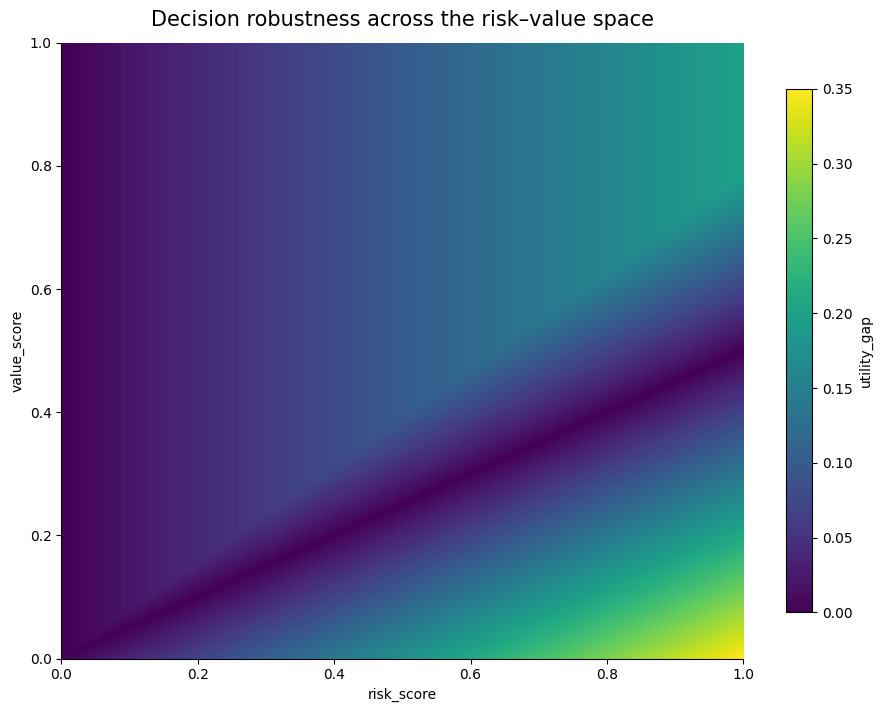

In [14]:

gap_surface = (
    grid.pivot(index="value_score", columns="risk_score", values="utility_gap")
    .sort_index(ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(
    gap_surface.values,
    origin="lower",
    aspect="auto",
    extent=[0, 1, 0, 1],
)
ax.set_title("Decision robustness across the risk–value space", fontsize=15, pad=12)
ax.set_xlabel("risk_score")
ax.set_ylabel("value_score")
cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("utility_gap")
plt.show()



### Utility-implied decision boundary

The next view makes the discrepancy more explicit: it shows the boundary implied by utility maximization rather than by policy thresholds.


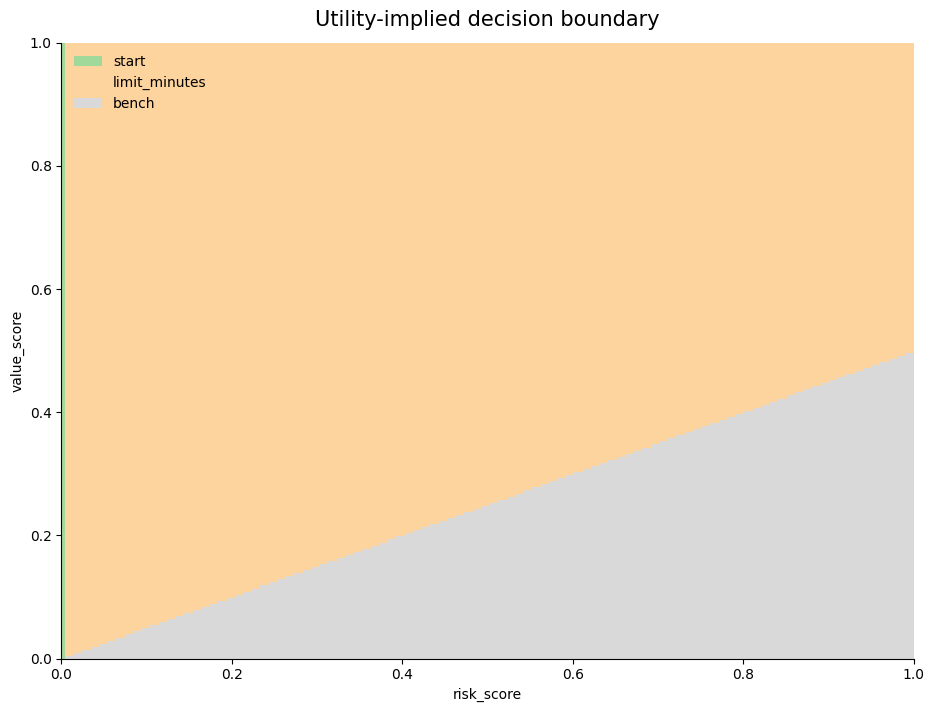

In [15]:

grid["utility_decision"] = grid["best_action_by_utility"]
grid["utility_decision_code"] = grid["utility_decision"].map(decision_map)

utility_decision_surface = (
    grid.pivot(index="value_score", columns="risk_score", values="utility_decision_code")
    .sort_index(ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 8))
ax.imshow(
    utility_decision_surface.values,
    origin="lower",
    aspect="auto",
    extent=[0, 1, 0, 1],
    cmap=policy_cmap,
    interpolation="nearest",
)
ax.set_title("Utility-implied decision boundary", fontsize=15, pad=12)
ax.set_xlabel("risk_score")
ax.set_ylabel("value_score")
ax.legend(handles=legend_elements, loc="upper left", frameon=False)
plt.show()



### Action dominance regions

This summary shows how much of the state space is dominated by each action under the current utility formulation.


In [16]:

dominance_summary = (
    grid["utility_decision"]
    .value_counts(normalize=True)
    .rename("share_of_state_space")
    .reset_index().rename(columns={"index": "action"})
)

dominance_summary


,utility_decision,share_of_state_space
0,limit_minutes,0.745
1,bench,0.250
2,start,0.005



## 6. Representative football archetypes

Decision systems become more convincing when they can describe recognizable player profiles rather than abstract coordinates.

Below we inspect a small set of football archetypes and compare:

- policy recommendation
- utility-implied action
- underlying utility values


In [17]:

archetypes = pd.DataFrame(
    [
        ("Explosive winger", 0.72, 0.91),
        ("Reliable centre-back", 0.18, 0.79),
        ("Rotational full-back", 0.80, 0.35),
        ("High-upside midfielder returning from overload", 0.64, 0.74),
        ("Low-impact available squad player", 0.20, 0.33),
        ("Borderline starter", 0.58, 0.66),
    ],
    columns=["player_profile", "risk_score", "value_score"],
)

archetypes["policy_decision"] = [
    classify_decision(r, v, thresholds, actions)
    for r, v in zip(archetypes["risk_score"], archetypes["value_score"])
]

archetypes["base_score"] = archetypes["value_score"] - risk_penalty * archetypes["risk_score"]
archetypes["u_start"] = archetypes["base_score"] - extra_start_penalty * archetypes["risk_score"]
archetypes["u_limit"] = archetypes["base_score"]
archetypes["u_bench"] = bench_multiplier * archetypes["base_score"]
archetypes["best_action_by_utility"] = (
    archetypes[["u_start", "u_limit", "u_bench"]]
    .idxmax(axis=1)
    .map(utility_action_map)
)
archetypes["mismatch"] = archetypes["policy_decision"] != archetypes["best_action_by_utility"]

archetypes.sort_values(["mismatch", "base_score"], ascending=[False, False])


,player_profile,risk_score,value_score,policy_decision,base_score,u_start,u_limit,u_bench,best_action_by_utility,mismatch
1,Reliable centre-back,0.180,0.790,start,0.700,0.664,0.700,0.210,limit_minutes,True
5,Borderline starter,0.580,0.660,start,0.370,0.254,0.370,0.111,limit_minutes,True
4,Low-impact available squad player,0.200,0.330,start,0.230,0.190,0.230,0.069,limit_minutes,True
0,Explosive winger,0.720,0.910,limit_minutes,0.550,0.406,0.550,0.165,limit_minutes,False
3,High-upside midfielder returning from overload,0.640,0.740,limit_minutes,0.420,0.292,0.420,0.126,limit_minutes,False
2,Rotational full-back,0.800,0.350,bench,-0.050,-0.210,-0.050,-0.015,bench,False


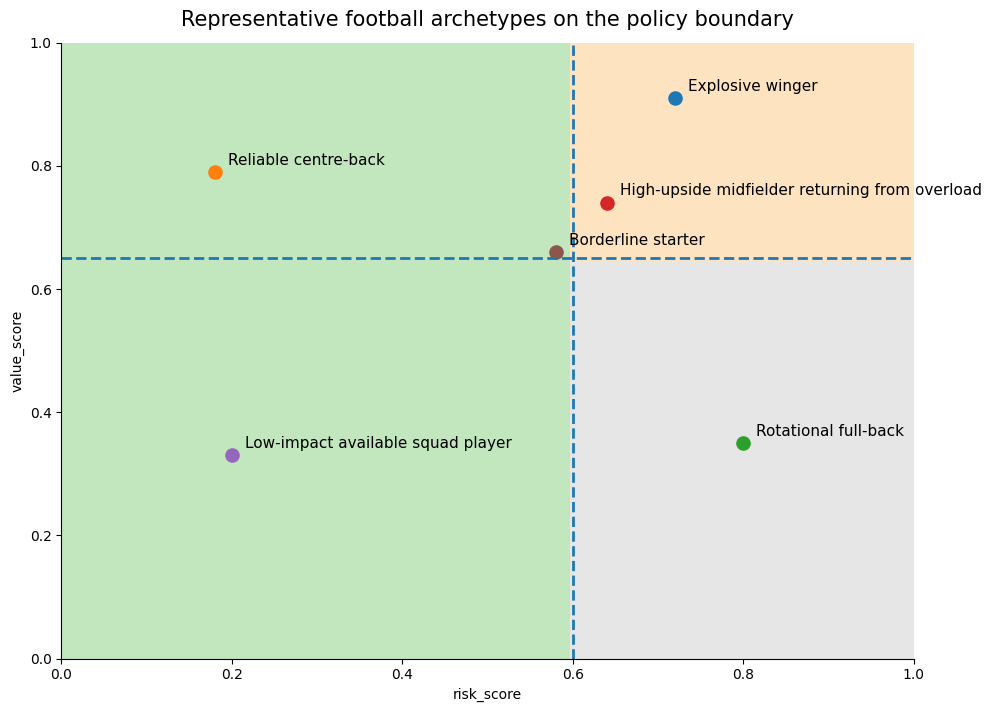

In [18]:

fig, ax = plt.subplots(figsize=(11, 8))

ax.imshow(
    surface.values,
    origin="lower",
    aspect="auto",
    extent=[0, 1, 0, 1],
    cmap=policy_cmap,
    interpolation="nearest",
    alpha=0.65,
)

ax.axvline(thresholds.high_risk, linestyle="--", linewidth=2)
ax.axhline(thresholds.high_value, linestyle="--", linewidth=2)

for _, row in archetypes.iterrows():
    ax.scatter(row["risk_score"], row["value_score"], s=90)
    ax.text(row["risk_score"] + 0.015, row["value_score"] + 0.012, row["player_profile"], fontsize=11)

ax.set_title("Representative football archetypes on the policy boundary", fontsize=15, pad=12)
ax.set_xlabel("risk_score")
ax.set_ylabel("value_score")
plt.show()



### Archetype interpretation

The archetypes reveal an important structural behavior in the current system:

- The **explosive winger** behaves exactly as intended: high upside justifies involvement, but exposure should be controlled
- The **rotational full-back** is consistently weak under both policy and utility views
- The **reliable centre-back** is more revealing: policy says `start`, but utility favors `limit_minutes`
- The **borderline starter** confirms that near-threshold players are especially sensitive to calibration choices

This is valuable from a portfolio standpoint because it shows not only what the system does, but also where its current assumptions should be challenged.



## 7. Sensitivity analysis

A robust decision system should make clear how behavior changes when risk aversion changes.

We therefore vary `risk_penalty` while preserving the same action-specific utility structure. This is a compact way to test whether the system is stable or highly policy-dependent.


In [19]:

risk_penalty_values = [0.20, 0.50, 0.80]
sensitivity_frames = []

for rp in risk_penalty_values:
    temp = grid[["risk_score", "value_score"]].copy()
    temp["risk_penalty"] = rp
    temp["base_score"] = temp["value_score"] - rp * temp["risk_score"]
    temp["u_start"] = temp["base_score"] - extra_start_penalty * temp["risk_score"]
    temp["u_limit"] = temp["base_score"]
    temp["u_bench"] = bench_multiplier * temp["base_score"]
    temp["best_action"] = (
        temp[["u_start", "u_limit", "u_bench"]]
        .idxmax(axis=1)
        .map(utility_action_map)
    )
    sensitivity_frames.append(temp)

sensitivity_df = pd.concat(sensitivity_frames, ignore_index=True)

sensitivity_summary = (
    sensitivity_df.groupby("risk_penalty")["best_action"]
    .value_counts(normalize=True)
    .rename("share_of_state_space")
    .reset_index()
)

sensitivity_summary


,risk_penalty,best_action,share_of_state_space
0,0.200,limit_minutes,0.893
1,0.200,bench,0.102
2,0.200,start,0.005
3,0.500,limit_minutes,0.745
4,0.500,bench,0.250
5,0.500,start,0.005
6,0.800,limit_minutes,0.595
7,0.800,bench,0.400
8,0.800,start,0.005


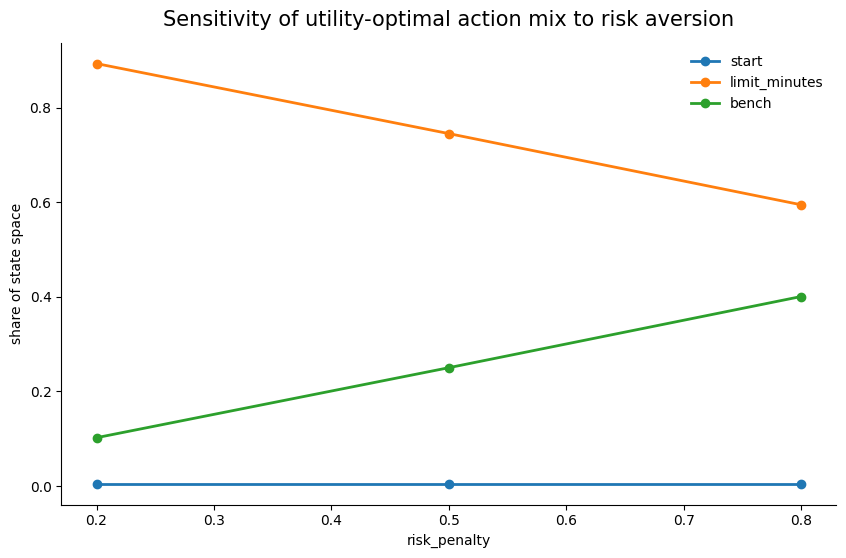

In [20]:

fig, ax = plt.subplots(figsize=(10, 6))

for action in ["start", "limit_minutes", "bench"]:
    subset = sensitivity_summary[sensitivity_summary["best_action"] == action]
    ax.plot(subset["risk_penalty"], subset["share_of_state_space"], marker="o", linewidth=2, label=action)

ax.set_title("Sensitivity of utility-optimal action mix to risk aversion", fontsize=15, pad=12)
ax.set_xlabel("risk_penalty")
ax.set_ylabel("share of state space")
ax.legend(frameon=False)
plt.show()



### Sensitivity interpretation

The sensitivity test usually tells a more interesting story than any single plot.

In the current formulation:

- `start` occupies only a very small fraction of the state space under utility maximization
- raising `risk_penalty` expands the `bench` region
- `limit_minutes` remains dominant across a wide range of assumptions

That means the current utility design is strongly biased toward controlled exposure. This is not necessarily wrong, but it is a substantive modeling choice that should be defended or recalibrated.



## 8. Conclusions

### Key findings

1. **The policy layer is clear and well-governed**  
   The threshold-based decision map is interpretable, auditable, and easy to communicate to football stakeholders.

2. **The optimization layer is materially different from the policy layer**  
   Under the current utility formulation, the best action is often `limit_minutes`, not `start`.

3. **The current formulation produces a high policy–utility mismatch**  
   This is the most important result in the notebook. It means the project already has genuine decision complexity, but it also means utility calibration now matters greatly.

4. **Controlled exposure is the dominant theme of the current model**  
   The model behaves less like a classic start-vs-bench selector and more like a three-action exposure-management engine.

5. **The notebook exposes a real calibration question, not a cosmetic one**  
   If a club wants more aggressive starting behavior, the current action utilities would need to be revisited.

### Football interpretation

From a football operations standpoint, the current system says:

- protect upside rather than expose it aggressively
- avoid giving unrestricted starts to players carrying meaningful risk
- reserve bench outcomes for low-utility states or strongly risk-averse settings

That is a coherent philosophy for congested schedules, fragile stars, and medical-risk governance.

### Modeling implication

The project is already beyond a conventional predictive portfolio piece. It is a **decision system** with explicit trade-offs, policy structure, and optimization logic.

The next modeling step is therefore not “add another model,” but rather:

- calibrate utility weights
- incorporate role and match context
- move from conceptual boundary analysis to realistic squad-level simulation



## 9. Limitations and next analytical step

### Current limitations

- No role-specific scarcity or formation constraints in the boundary analysis  
- No opponent, competition, or game-state context  
- No uncertainty intervals around `risk_score` and `value_score`  
- Utility structure currently favors `limit_minutes` very strongly

### Recommended next notebook

The most valuable follow-up is a **matchday simulation notebook** that:

- creates a realistic squad list
- runs raw policy decisions and optimized decisions side by side
- shows where squad constraints force trade-offs
- interprets outcomes by role, game context, and exposure strategy

That would convert this notebook from conceptual decision geometry into a matchday decision-support workflow.


In [21]:

# Optional: save figures for README or documentation assets
# Uncomment any line below if you want exported images.

# fig.savefig("outputs/decision_boundary_policy.png", dpi=200, bbox_inches="tight")
# fig.savefig("outputs/decision_boundary_utility.png", dpi=200, bbox_inches="tight")
